## Atelier : Découverte du Clustering et de l'Apprentissage Non Supervisé

L’apprentissage non supervisé est une branche du Machine Learning dans laquelle le modèle apprend à partir de **données non étiquetées**, c’est-à-dire des données pour lesquelles aucune sortie  (label) n’est fournie.

Contrairement à l’apprentissage supervisé, où le modèle apprend en comparant ses prédictions à des réponses connues.

Le modèle doit donc découvrir seul la structure interne des données.

**Qu'est-ce qu'une donnée non étiquetée ?**

Une donnée non étiquetée ne possède **que** des caractéristiques (features) sans information sur la catégorie ou le résultat attendu.


### Exemple concret : Analyse de clients d'une boutique en ligne

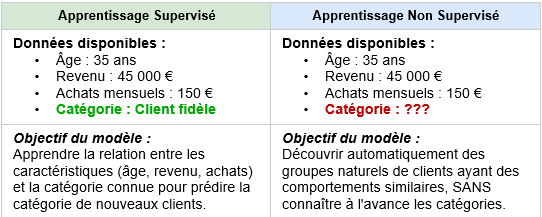

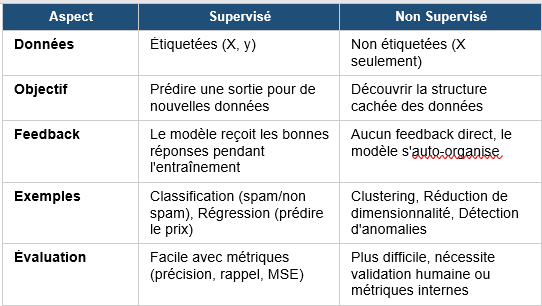

### Types de l’Apprentissage Non Supervisé :

### 1️⃣ Clustering (Regroupement)

Définition

Le clustering consiste à regrouper les données en plusieurs groupes (clusters) tels que :



*   les éléments d’un même groupe sont très similaires
*   les éléments de groupes différents sont très différents






 Les groupes ne sont pas connus à l’avance.

Principaux algorithmes:


1.   K-Means
2.   Clustering hiérarchique
3. DBSCAN










### 2️⃣ Réduction de Dimension

 Définition

La réduction de dimension vise à réduire le nombre de variables tout en conservant le maximum d’information.

 Elle permet de transformer des données complexes en une représentation plus simple.

Principaux algorithmes:


1.   PCA (Analyse en Composantes Principales)
2.   t-SNE

3. Autoencoders








### 3️⃣ Détection d’Anomalies (Outliers)

Définition

La détection d’anomalies consiste à identifier les données rares ou atypiques qui ne suivent pas le comportement général.

Principaux algorithmes:



1.   Isolation Forest
2.   One-Class SVM
3. Autoencoders











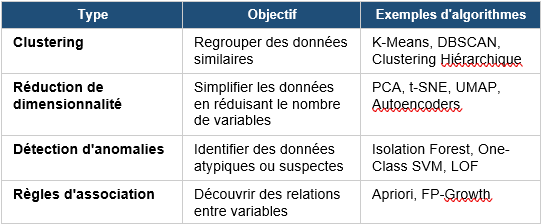

## clustering

Après avoir exploré les fondements de l’apprentissage non supervisé et ses différents types, nous allons maintenant nous concentrer sur l’une de ses applications les plus importantes et les plus utilisées : le clustering.

**Cette technique vise à organiser automatiquement des données non étiquetées en groupes homogènes, en s’appuyant sur des mesures de similarité et de distance.**


  

**Applications Concrètes:**

Le clustering trouve des applications dans de nombreux domaines :

1.	Marketing : Segmentation client pour cibler des campagnes publicitaires
2.	Biologie : Classification d'espèces, analyse génétique
3.	Médecine : Identification de groupes de patients avec symptômes similaires
4.	E-commerce : Systèmes de recommandation de produits
5.	Analyse d'images : Segmentation et compression d'images
6.	Réseaux sociaux : Détection de communautés d'utilisateurs


**Définition et Concept**:

Le clustering est une technique d'apprentissage non supervisé qui consiste à regrouper des données en groupes homogènes appelés clusters.

 Les éléments d'un même cluster partagent des caractéristiques similaires, tandis qu'ils diffèrent des éléments des autres clusters.

Principe fondamental : Maximiser la similarité intra-cluster et minimiser la similarité inter-clusters.


### K-Means


K-Means est l'algorithme de clustering (regroupement) . Son nom vient de K (nombre de groupes) et Means (moyenne).

**Description :**

 Il partitionne les données en K clusters en assignant chaque point au centroïde le plus proche.

**Fonctionnement :**


*  ÉTAPE 0 : Choisir K
:

   Décider combien de groupes nous voulons. C'est l'utilisateur qui choisit K en fonction des besoins métier ou avec des méthodes statistiques (méthode du coude).

*   ÉTAPE 1 : Initialisation

    Centroïde = point représentant le centre d'un cluster (comme le capitaine d'une équipe).
    L'algorithme place aléatoirement K centroïdes parmi les données. Ces centres temporaires seront progressivement ajustés.



*   ÉTAPE 2 : Assignation

    Pour chaque client, calculer la distance euclidienne vers les 3 centroïdes, puis l'assigner au plus proche.

*   ÉTAPE 3 : Mise à Jour

    Recalculer la position de chaque centroïde comme la moyenne de tous les points de son cluster.



*   ÉTAPE 4 : Convergence

    Retour à l'étape 2 : réassigner chaque point (les centroïdes ont bougé !), puis recalculer les centroïdes.








### Schéma Récapitulatif

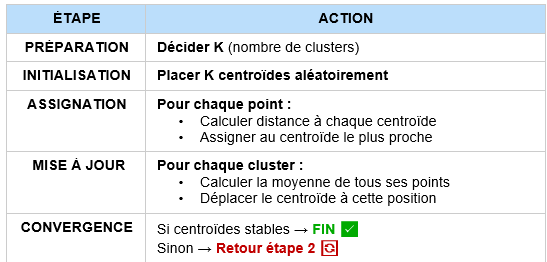

### Visualisation:

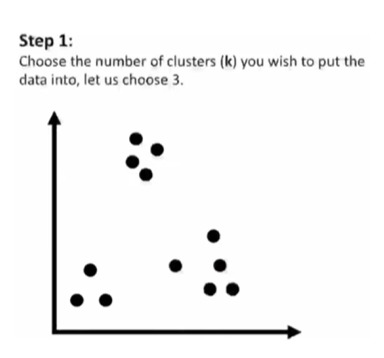

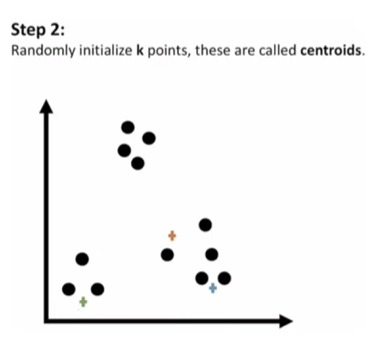

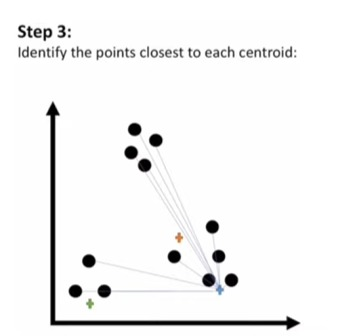

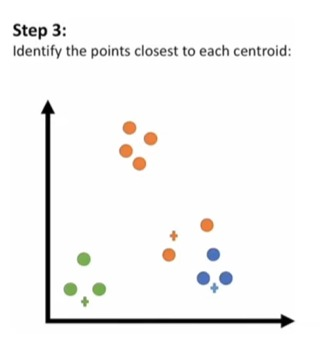

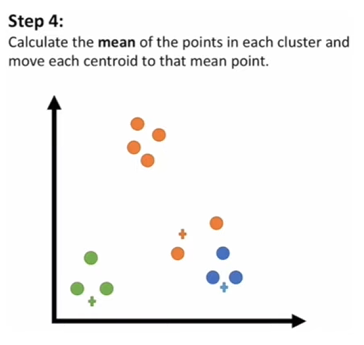

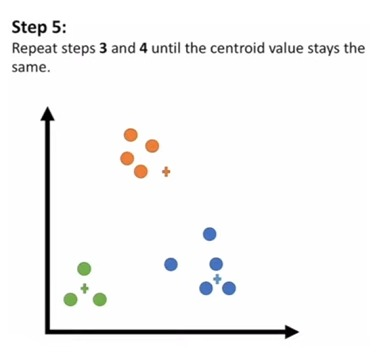

L'algorithme s'arrête quand :

1.	Les centroïdes ne bougent plus (ou très peu)
2.	Les assignations ne changent plus


### Comment Choisir K ?

le nombre de clusters (groupes) que l’on souhaite former dans les données

⚠️ K n’est pas appris automatiquement par l’algorithme :
c’est l’utilisateur qui doit le fixer avant d’exécuter K-means.

Pourquoi le choix de K est important ?

Un K trop petit → les clusters sont trop larges, on perd de l’information

Un K trop grand → les clusters sont trop fragmentés, bruit et sur-apprentissage

 L’objectif est donc de trouver un bon compromis.

### 1️⃣ Méthode du coude (Elbow Method)
**Principe:**

On exécute K-means pour plusieurs valeurs de K

On calcule l’inertie (ou WCSS) :

somme des distances entre les points et leur centroïde.

 Plus K augmente → l’inertie diminue
 On choisit K au niveau du coude (diminution moins significative)



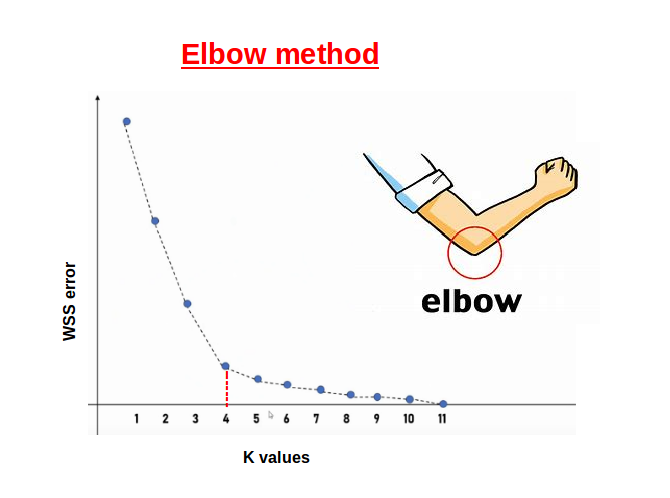

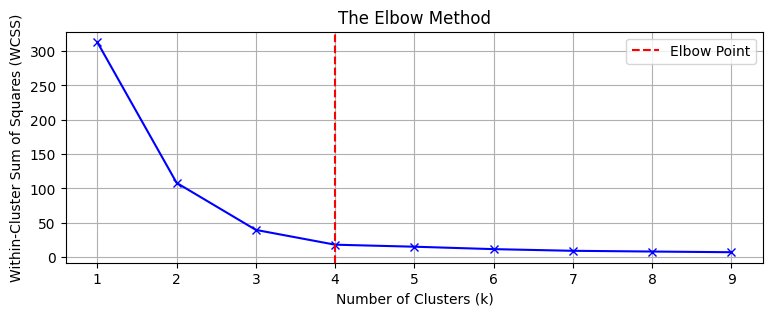

### pourquoi on ne choisit pas K maximal, mais K du coude ?

Données

On considère un jeu de données contenant 100 points.

Cas : K = 80 (K très grand, mais pas maximal)
Que fait K-means ?

Les 100 points sont répartis en 80 clusters

Cela implique :

80 clusters contiennent 1 seul point

20 points sont regroupés dans quelques clusters

 La majorité des clusters sont triviaux (1 point).

🔹 Calcul de l’inertie (intuitivement)

Pour les clusters à 1 point
 :$$\|x - \mu\| = 0$$

 Pour les quelques clusters à plusieurs points :$$\|x - \mu\| > 0$$

➡️ L’inertie totale est faible, mais pas nulle

Alors, où est le problème ?


>  Perte de sens du clustering



Le but du clustering est de regrouper des points similaires

Avec K = 80 :

la plupart des clusters ne contiennent qu’un point

il n’y a presque plus de regroupement

👉 On ne découvre aucune structure globale


> Faible interprétabilité




80 clusters sont :

difficiles à analyser

impossibles à exploiter métier

inutiles pour la prise de décision

👉 On ne peut pas donner de sens à autant de groupes

2️⃣ Méthode du coefficient de silhouette

Principe:


*   Mesure la qualité des clusters

*   Valeur entre -1 et 1






| Valeur          | Interprétation              |
| --------------- | --------------------------- |
| proche de **1** | clusters bien séparés       |
| proche de **0** | clusters qui se chevauchent |
| négatif         | mauvais clustering          |


On choisit le K qui maximise le score de silhouette.

Résumé général de l’atelier

Dans cet atelier, nous avons découvert les fondements théoriques de l’apprentissage non supervisé, en nous concentrant principalement sur la notion de clustering.

L’objectif était de comprendre les idées clés, le vocabulaire et les concepts essentiels permettant d’analyser et de structurer des données sans information préalable.

Nous avons abordé les principes généraux du clustering, son intérêt dans l’analyse de données, ainsi que les enjeux liés au regroupement des données et à l’interprétation des résultats.


Cet atelier constitue une base théorique indispensable.

Dans les prochains ateliers, nous passerons à la mise en pratique, notamment à travers l’application de l’algorithme K-means sur des jeux de données réels, afin de concrétiser les notions étudiées.

Par ailleurs, les ateliers suivants ne se limiteront pas uniquement au clustering :
nous explorerons d’autres problématiques de l’apprentissage non supervisé et de l’intelligence artificielle, afin d’élargir la vision globale et les cas d’usage possibles.